# Case Study 1 — Cross-technique results summary (EXP-0, EXP-1, EXP-2)

## 1. Clone or refresh repository

In [1]:
from pathlib import Path
import os
import sys

REPO_URL = "https://github.com/EnomisLP/DiverseVul--IS-Project.git"
BRANCH = "prashant"
REPO_DIR = Path("/content/DiverseVul--IS-Project")

if not REPO_DIR.exists():
    !git clone --depth 1 --branch {BRANCH} {REPO_URL} {REPO_DIR}
else:
    os.chdir(REPO_DIR)
    !git fetch origin {BRANCH}
    !git checkout {BRANCH}
    !git pull --ff-only origin {BRANCH}

PROJECT_DIR = REPO_DIR / "vuln-detection"
SRC_DIR = PROJECT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

os.chdir(PROJECT_DIR)

print("Repository:", REPO_DIR)
print("Project directory:", PROJECT_DIR)
print("Current working directory:", Path.cwd())

Cloning into '/content/DiverseVul--IS-Project'...
remote: Enumerating objects: 62, done.
remote: Counting objects: 100% (62/62), done.
remote: Compressing objects: 100% (56/56), done.
remote: Total 62 (delta 6), reused 47 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (62/62), 842.28 KiB | 8.68 MiB/s, done.
Resolving deltas: 100% (6/6), done.
Repository: /content/DiverseVul--IS-Project
Project directory: /content/DiverseVul--IS-Project/vuln-detection
Current working directory: /content/DiverseVul--IS-Project/vuln-detection


## 2. Mount Google Drive and define output roots

In [2]:
from google.colab import drive

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData")
OUTPUT_ROOT = DRIVE_ROOT / "outputs"
EXPERIMENT_ID = "cs1_project_holdout20_innercv_v1"

print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("EXPERIMENT_ID:", EXPERIMENT_ID)

Mounted at /content/drive
OUTPUT_ROOT: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs
EXPERIMENT_ID: cs1_project_holdout20_innercv_v1


## 3. Locate saved experiment output directories

In [3]:
EXP0_RESULTS_DIR = OUTPUT_ROOT / "exp0_idabs_nested_alpha_development_only_v2_reproduction"
EXP1_DEV_DIR = OUTPUT_ROOT / EXPERIMENT_ID / "exp1_rf_idabs_dev_cv_v1"
EXP1_HOLDOUT_DIR = OUTPUT_ROOT / EXPERIMENT_ID / "exp1_rf_idabs_final_holdout_v1"
EXP2_DEV_DIR = OUTPUT_ROOT / EXPERIMENT_ID / "exp2_mlp_idabs_dev_cv_v2"
EXP2_HOLDOUT_DIR = OUTPUT_ROOT / EXPERIMENT_ID / "exp2_mlp_idabs_final_holdout_v2"
RESULTS_OUTPUT_DIR = OUTPUT_ROOT / EXPERIMENT_ID / "cs1_results_summary"

for directory in [EXP0_RESULTS_DIR, EXP1_DEV_DIR, EXP1_HOLDOUT_DIR, EXP2_DEV_DIR, EXP2_HOLDOUT_DIR]:
    if not directory.exists():
        raise FileNotFoundError(
            f"Expected experiment output directory not found: {directory}"
        )

RESULTS_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("All five experiment output directories found.")
print("Results will be saved to:", RESULTS_OUTPUT_DIR)

All five experiment output directories found.
Results will be saved to: /content/drive/MyDrive/IntelligentSystemProject/VulnerabilityDetectionData/outputs/cs1_project_holdout20_innercv_v1/cs1_results_summary


## 4. Define a robust predictions loader

In [4]:
import pandas as pd

def load_predictions(directory, pattern):
    matches = sorted(directory.glob(pattern))
    if not matches:
        matches = sorted(directory.glob(pattern.replace(".parquet", ".csv")))
    if not matches:
        raise FileNotFoundError(f"No file matching \'{pattern}\' found in {directory}")
    if len(matches) > 1:
        raise RuntimeError(f"Multiple files matching \'{pattern}\' found in {directory}: {matches}")
    path = matches[0]
    if path.suffix == ".parquet":
        return pd.read_parquet(path)
    return pd.read_csv(path)

## 5. Load development-CV and holdout predictions for all three experiments

In [5]:
exp0_dev_predictions = load_predictions(EXP0_RESULTS_DIR, "*oof_predictions*.parquet")
exp0_holdout_predictions = load_predictions(EXP0_RESULTS_DIR, "*holdout_predictions*.parquet")
exp1_dev_predictions = load_predictions(EXP1_DEV_DIR, "*oof_predictions*.parquet")
exp1_holdout_predictions = load_predictions(EXP1_HOLDOUT_DIR, "*holdout_predictions*.parquet")
exp2_dev_predictions = load_predictions(EXP2_DEV_DIR, "*oof_predictions*.parquet")
exp2_holdout_predictions = load_predictions(EXP2_HOLDOUT_DIR, "*holdout_predictions*.parquet")

print("EXP-0 dev rows:", len(exp0_dev_predictions), "| holdout rows:", len(exp0_holdout_predictions))
print("EXP-1 dev rows:", len(exp1_dev_predictions), "| holdout rows:", len(exp1_holdout_predictions))
print("EXP-2 dev rows:", len(exp2_dev_predictions), "| holdout rows:", len(exp2_holdout_predictions))

EXP-0 dev rows: 203958 | holdout rows: 57709
EXP-1 dev rows: 203958 | holdout rows: 57709
EXP-2 dev rows: 203958 | holdout rows: 57709


## 6. Validate that all three experiments share the same frozen holdout partition

In [6]:
holdout_project_sets = {
    "EXP-0": set(exp0_holdout_predictions["project"].unique()),
    "EXP-1": set(exp1_holdout_predictions["project"].unique()),
    "EXP-2": set(exp2_holdout_predictions["project"].unique()),
}

reference = holdout_project_sets["EXP-0"]
for name, projects in holdout_project_sets.items():
    if projects != reference:
        raise ValueError(
            f"{name} holdout projects differ from EXP-0\'s holdout projects."
        )

print("All three experiments share the identical", len(reference), "-project outer holdout.")

All three experiments share the identical 203 -project outer holdout.


## 7. Compute project-block bootstrap confidence intervals per experiment

In [7]:
import case_study_1.confidence_intervals as confidence_intervals

experiment_predictions = {
    "EXP-0 (LR)": {"dev": exp0_dev_predictions, "holdout": exp0_holdout_predictions},
    "EXP-1 (RF)": {"dev": exp1_dev_predictions, "holdout": exp1_holdout_predictions},
    "EXP-2 (MLP)": {"dev": exp2_dev_predictions, "holdout": exp2_holdout_predictions},
}

ci_results = {}
for name, partitions in experiment_predictions.items():
    ci_results[name] = {
        split: confidence_intervals.bootstrap_metric_ci(
            frame,
            metric="average_precision_pr_auc",
            n_bootstrap=1000,
            random_state=42,
        )
        for split, frame in partitions.items()
    }
    for split, result in ci_results[name].items():
        print(f"{name} [{split}]")
        print(confidence_intervals.format_ci_report(result))
        print()

EXP-0 (LR) [dev]
average_precision_pr_auc: point estimate = 0.1369
  95% CI (project-block bootstrap): [0.1184, 0.1617]
  valid resamples: 1000/1000 (0 degenerate, dropped)
  n_projects: 594, random_state=42
  Reflects sampling variability within this dataset only; not an estimate of generalization to C functions outside this collection.

EXP-0 (LR) [holdout]
average_precision_pr_auc: point estimate = 0.1458
  95% CI (project-block bootstrap): [0.1230, 0.1730]
  valid resamples: 1000/1000 (0 degenerate, dropped)
  n_projects: 203, random_state=42
  Reflects sampling variability within this dataset only; not an estimate of generalization to C functions outside this collection.

EXP-1 (RF) [dev]
average_precision_pr_auc: point estimate = 0.1240
  95% CI (project-block bootstrap): [0.1028, 0.1528]
  valid resamples: 1000/1000 (0 degenerate, dropped)
  n_projects: 594, random_state=42
  Reflects sampling variability within this dataset only; not an estimate of generalization to C functions

## 8. Summary table of PR-AUC with confidence intervals

In [8]:
summary_rows = []
for name, splits in ci_results.items():
    row = {"experiment": name}
    for split, result in splits.items():
        row[f"{split}_pr_auc"] = result.point_estimate
        row[f"{split}_ci_low"] = result.ci_low
        row[f"{split}_ci_high"] = result.ci_high
    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows)
summary_table

,experiment,dev_pr_auc,dev_ci_low,dev_ci_high,holdout_pr_auc,holdout_ci_low,holdout_ci_high
0,EXP-0 (LR),0.136888,0.118440,0.161690,0.145765,0.122995,0.172953
1,EXP-1 (RF),0.124013,0.102772,0.152817,0.143290,0.111499,0.190850
2,EXP-2 (MLP),0.137544,0.116147,0.163691,0.136699,0.114463,0.164164


## 9. Bar chart: development vs. holdout PR-AUC across all three techniques

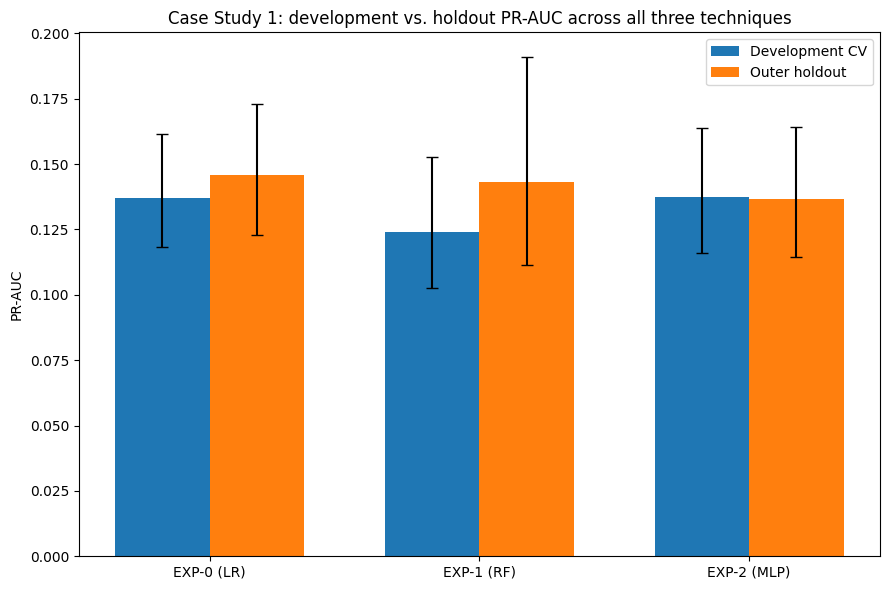

In [9]:
import matplotlib.pyplot as plt
import numpy as np

names = list(experiment_predictions.keys())
x = np.arange(len(names))
width = 0.35

dev_points = [ci_results[n]["dev"].point_estimate for n in names]
dev_low = [ci_results[n]["dev"].point_estimate - ci_results[n]["dev"].ci_low for n in names]
dev_high = [ci_results[n]["dev"].ci_high - ci_results[n]["dev"].point_estimate for n in names]

holdout_points = [ci_results[n]["holdout"].point_estimate for n in names]
holdout_low = [ci_results[n]["holdout"].point_estimate - ci_results[n]["holdout"].ci_low for n in names]
holdout_high = [ci_results[n]["holdout"].ci_high - ci_results[n]["holdout"].point_estimate for n in names]

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar(x - width / 2, dev_points, width, yerr=[dev_low, dev_high], capsize=4, label="Development CV")
ax.bar(x + width / 2, holdout_points, width, yerr=[holdout_low, holdout_high], capsize=4, label="Outer holdout")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("PR-AUC")
ax.set_title("Case Study 1: development vs. holdout PR-AUC across all three techniques")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_OUTPUT_DIR / "cs1_all_techniques_pr_auc_ci.png")
plt.show()

## 10. Precision-recall curves on the outer holdout

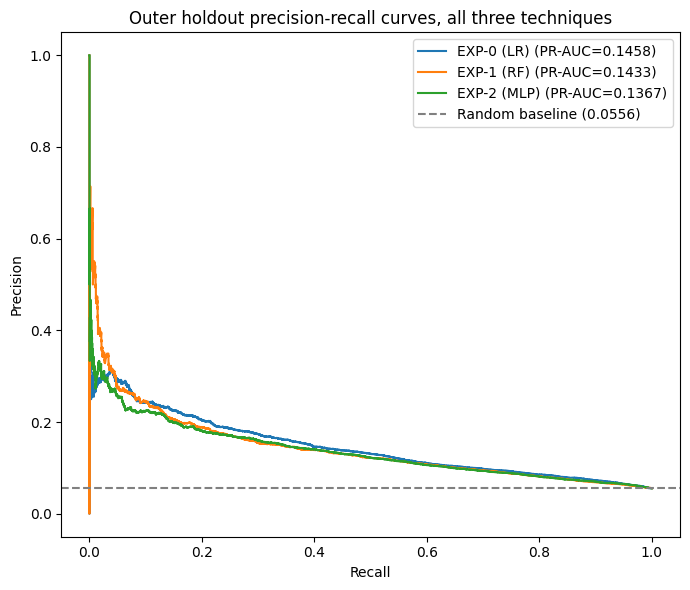

In [10]:
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(7, 6))
for name, frame in [
    ("EXP-0 (LR)", exp0_holdout_predictions),
    ("EXP-1 (RF)", exp1_holdout_predictions),
    ("EXP-2 (MLP)", exp2_holdout_predictions),
]:
    precision, recall, _ = precision_recall_curve(frame["label"], frame["y_score"])
    pr_auc = ci_results[name]["holdout"].point_estimate
    ax.plot(recall, precision, label=f"{name} (PR-AUC={pr_auc:.4f})")

positive_rate = exp0_holdout_predictions["label"].mean()
ax.axhline(positive_rate, linestyle="--", color="gray", label=f"Random baseline ({positive_rate:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Outer holdout precision-recall curves, all three techniques")
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_OUTPUT_DIR / "cs1_all_techniques_pr_curves_holdout.png")
plt.show()

## 11. Paired bootstrap comparison between techniques on the outer holdout

In [11]:
pairs = [
    ("EXP-0 (LR)", "EXP-1 (RF)"),
    ("EXP-0 (LR)", "EXP-2 (MLP)"),
    ("EXP-1 (RF)", "EXP-2 (MLP)"),
]

paired_results = {}
for name_a, name_b in pairs:
    result = confidence_intervals.paired_bootstrap_metric_ci(
        experiment_predictions[name_a]["holdout"],
        experiment_predictions[name_b]["holdout"],
        name_a,
        name_b,
        n_bootstrap=1000,
        random_state=42,
    )
    paired_results[(name_a, name_b)] = result
    print(confidence_intervals.format_paired_ci_report(result))
    print()

average_precision_pr_auc: EXP-0 (LR) = 0.1458, EXP-1 (RF) = 0.1433
  Difference (EXP-0 (LR) - EXP-1 (RF)) = 0.0025
  95% CI on the difference (paired project-block bootstrap): [-0.0218, 0.0178]
  valid resamples: 1000/1000 (0 degenerate, dropped)
  An interval excluding zero means the difference is unlikely to be bootstrap noise within this dataset; it says nothing about generalization beyond it.

average_precision_pr_auc: EXP-0 (LR) = 0.1458, EXP-2 (MLP) = 0.1367
  Difference (EXP-0 (LR) - EXP-2 (MLP)) = 0.0091
  95% CI on the difference (paired project-block bootstrap): [0.0032, 0.0151]
  valid resamples: 1000/1000 (0 degenerate, dropped)
  An interval excluding zero means the difference is unlikely to be bootstrap noise within this dataset; it says nothing about generalization beyond it.

average_precision_pr_auc: EXP-1 (RF) = 0.1433, EXP-2 (MLP) = 0.1367
  Difference (EXP-1 (RF) - EXP-2 (MLP)) = 0.0066
  95% CI on the difference (paired project-block bootstrap): [-0.0083, 0.0286]
 

## 12. Save summary and comparison tables

In [12]:
summary_table.to_csv(RESULTS_OUTPUT_DIR / "cs1_all_techniques_summary.csv", index=False)

paired_rows = [
    {
        "experiment_a": result.experiment_a,
        "experiment_b": result.experiment_b,
        "pr_auc_a": result.point_estimate_a,
        "pr_auc_b": result.point_estimate_b,
        "difference": result.point_estimate_diff,
        "ci_low": result.ci_low_diff,
        "ci_high": result.ci_high_diff,
    }
    for result in paired_results.values()
]
paired_table = pd.DataFrame(paired_rows)
paired_table.to_csv(RESULTS_OUTPUT_DIR / "cs1_all_techniques_paired_holdout_comparisons.csv", index=False)
paired_table

,experiment_a,experiment_b,pr_auc_a,pr_auc_b,difference,ci_low,ci_high
0,EXP-0 (LR),EXP-1 (RF),0.145765,0.143290,0.002475,-0.021767,0.017789
1,EXP-0 (LR),EXP-2 (MLP),0.145765,0.136699,0.009067,0.003164,0.015149
2,EXP-1 (RF),EXP-2 (MLP),0.143290,0.136699,0.006591,-0.008288,0.028631
